In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
from scipy.interpolate import CubicSpline
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

import time
import datetime

In [2]:
%matplotlib widget
plt.close('all')

# Ordine LO

In breve, rifacendoci alla teoria già spiegata in relazione, l'interazione nucleare mescola onde appartenenti allo stesso canale, ma NON PUÒ prendere un'onda di un canale e trasformarla nell'onda di un altro canale. In pratica, questo vuol dire che noi separeremo l'inferenza invece di farla su tutti i parametri contemporaneamente.

All'ordine LO abbiamo comunque due canali, quello singolo di 1S0 e quello accoppiato di 3S1. Per ciascun canale, però, il modello teorico prevede una sola LEC, quindi noi facciamo due run in cui inferiamo su un parametro solo ciascuna. Dopotutto, tutte le run precedenti (che possiamo chiamare "preliminari") hanno confermato la totale assenza di correlazione.

In [3]:
T_Lab = granada.Tlabs 

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

In [4]:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) 
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) 

## Canale 1S0:

In [5]:
def ln_prior_LO_1S0(parameters):
    C_1S0 = parameters
    
    # Prior gaussiano di media 0 e sigma 1.5, senza cut-off:
    ln_P_1S0 = -0.5 * ( np.log(2.0*np.pi * 2.25) + C_1S0**2 / 2.25 )
    return ln_P_1S0

def ln_likelihood_LO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0):
    LO_lecs = {}
    LO_lecs["C_1S0"] = parameters[0]
    LO_lecs["C_3S1"] = 0.0
    nnstudio.lecs = LO_lecs
    
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]

    ln_L_1S0 = -0.5 * np.sum( np.log(2.0*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    return ln_L_1S0

def ln_posterior_LO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0):
    ln_pr = ln_prior_LO_1S0(parameters)    
    ln_post = ln_pr + ln_likelihood_LO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0)
    return ln_post

In [6]:
# Prima run: caso LO, canale 1S0
ndim = 1
nwalkers = 10*ndim
nsteps = 5000 # da far andare, tempo di autocorrelazione è tipo 20

initial_guess = np.array([-0.10])
initial_positions = initial_guess + 0.01 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            ln_posterior_LO_1S0,
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error),
            pool=pool,
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(initial_positions, nsteps, progress=True)
    print("\nFinito! :)\n")

Eseguendo su 12 core...


100%|██████████| 5000/5000 [24:06<00:00,  3.46it/s]


Finito! :)



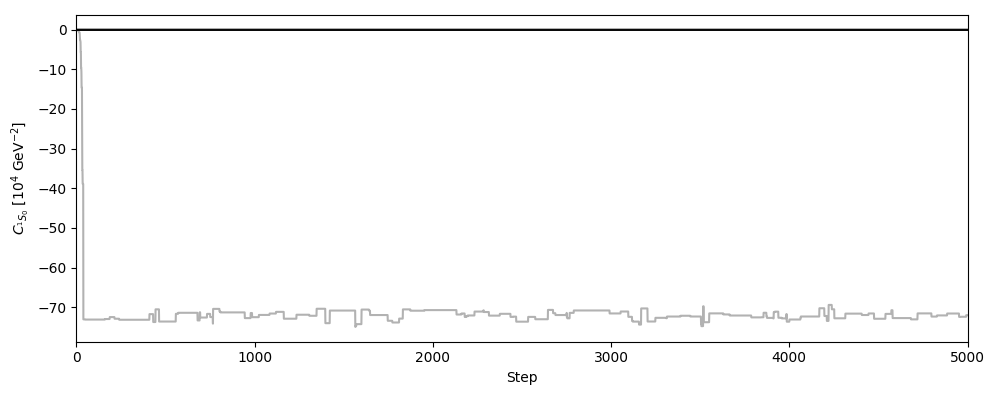

In [7]:
full_chain_LO_1S0 = sampler.get_chain()
np.save("full_chain_LO_1S0.npy", full_chain_LO_1S0)

labels = [r"$C_{^1S_0}$ [$10^4$ GeV$^{-2}$]"]
fig, axes = plt.subplots(ndim, figsize=(10, 4*len(labels)), sharex=True)

# Sintassi di rinormalizzazione subplots (per uniformare il codice successivo):
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]

for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(full_chain_LO_1S0[:, walker, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.set_xlim(0, len(full_chain_LO_1S0))
    ax.yaxis.set_label_coords(-0.05, 0.5)
axes[-1].set_xlabel("Step")
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
plt.show()

In [8]:
tau_LO_1S0 = sampler.get_autocorr_time() # Tipicamente poco al di sopra di 25 => run ufficiale da 1500 step
print(f"\nTempo di autocorrelazione per C_1S0 in caso LO: {tau_LO_1S0[0]:.1f} step")

discard_LO_1S0 = 5 * int(max(tau_LO_1S0))
print(f"\nConseguente numero di step di termalizzazione: {discard_LO_1S0} step")

thin_LO_1S0 = int(min(tau_LO_1S0))
print(f"\nConseguente numero di step per il thinning: {thin_LO_1S0} step")


Tempo di autocorrelazione per C_1S0 in caso LO: 16.1 step

Conseguente numero di step di termalizzazione: 80 step

Conseguente numero di step per il thinning: 16 step


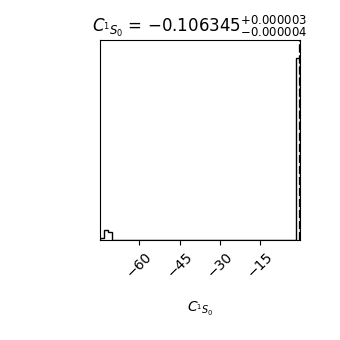

In [9]:
# Per il corner plot triviale:
flat_samples_LO_1S0 = sampler.get_chain(discard=discard_LO_1S0, thin=thin_LO_1S0, flat=True)
labels = [r"$C_{^1S_0}$"]

figure = corner.corner(
    flat_samples_LO_1S0,
    labels=labels,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    title_fmt=".6f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=50,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

#

## Canale 3S1:

In [10]:
def ln_prior_LO_3S1(parameters):
    C_3S1 = parameters
    ln_P_3S1 = -0.5 * ( np.log(2.0*np.pi * 2.25) + C_3S1**2 / 2.25 )
    return ln_P_3S1

def ln_likelihood_LO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    LO_lecs = {}
    LO_lecs["C_1S0"] = 0.0
    LO_lecs["C_3S1"] = parameters[0]
    nnstudio.lecs = LO_lecs
    
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:, 0]
    teo_3D1 = nnstudio.phase_shifts[0][:, 1]
    teo_mix = nnstudio.phase_shifts[0][:, 2]
    
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    ln_L_3D1 = -0.5 * np.sum( np.log(2*np.pi * err_3D1**2) + ((exp_3D1-teo_3D1) / err_3D1)**2 )
    ln_L_mix = -0.5 * np.sum( np.log(2*np.pi * err_mix**2) + ((exp_mix-teo_mix) / err_mix)**2 )

    # Calcolo dell'energia:
    
    _, mu = nnstudio.lab2rel(0, 0)
    N = 2 * nnstudio.Np
    H = np.zeros((N, N))
    T = np.zeros((N, N))
    ww = np.hstack((nnstudio.wmesh, nnstudio.wmesh))
    pp = np.hstack((nnstudio.pmesh, nnstudio.pmesh))
    V = nnstudio.setup_Vmtx(chn_3S1[0])[0]
    
    for i, p_bra in enumerate(pp):
        for j, p_ket in enumerate(pp):
            if i == j:
                T[i, j] = p_bra**2 / (2 * mu)
            V[i, j] = V[i, j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
    H = T + V
    eigvals, eigvecs = linalg.eigh(H)
    srt = np.argsort(eigvals)
    E_teo = eigvals[srt[0]]

    E_obs = -2.224
    E_err = -E_obs * 0.05 # Impostiamo un errore del 5% sul modello
    ln_L_E = -0.5 * ( np.log(2.0*np.pi * E_err**2) + ((E_obs - E_teo) / E_err)**2 )

    # Calcolo del quadrupolo:
    
    #phi_gs = eigvecs[:, srt[0]]
    #psi_gs = phi_gs / (pp * np.sqrt(ww))
    #u = psi_gs[:nnstudio.Np]
    #w = psi_gs[nnstudio.Np:]
    #if u[np.argmax(np.abs(u))] < 0:
    #    u *= -1
    #    w *= -1
    #idx = np.argsort(nnstudio.pmesh)
    #p = nnstudio.pmesh[idx]
    #spline_u = CubicSpline(p, u[idx])
    #spline_w = CubicSpline(p, w[idx])
    #du = spline_u(p, 1)
    #dw = spline_w(p, 1)
    #u = u[idx]
    #w = w[idx]
    #wmesh = nnstudio.wmesh[idx]
    #
    #SD_term = (-np.sqrt(8)/20) * (p**2 * dw * du + 3 * p * w * du)
    #DD_term = (-1/20) * (p**2 * dw**2 + 6 * w**2)
    #Q_teo = np.sum(wmesh * (SD_term + DD_term))
    #Q_teo *= hbarc**2
    #if Q_teo < 0:
    #    Q_teo *= -1
    #
    #Q_obs = 0.286
    #Q_err = Q_obs * 0.05 # Anche qui, 5% di errore
    #ln_L_Q = -0.5 * ( np.log(2.0*np.pi * Q_err**2) + ((Q_obs - Q_teo) / Q_err)**2 )

    # Abbiamo una somma di 5 likelihood che consideriamo indipendenti:
    return ln_L_3S1 + ln_L_3D1 + ln_L_mix + ln_L_E #+ ln_L_Q

def ln_posterior_LO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    ln_pr = ln_prior_LO_3S1(parameters)    
    ln_post = ln_pr + ln_likelihood_LO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix)
    return ln_post

In [11]:
# Seconda run: caso LO, canale 3S1
ndim = 1
nwalkers = 10*ndim
nsteps = 1500

initial_guess = np.array([-0.10])
initial_positions = initial_guess + 0.01 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            ln_posterior_LO_3S1,
            args=(nn, channel_3S1, shift_3S1, shift_3S1_error, shift_3D1, shift_3D1_error, shift_mix, shift_mix_error),
            pool=pool,
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(initial_positions, nsteps, progress=True)
    print("\nFinito! :)\n")

Eseguendo su 12 core...


100%|██████████| 1500/1500 [1:20:42<00:00,  3.23s/it]


Finito! :)



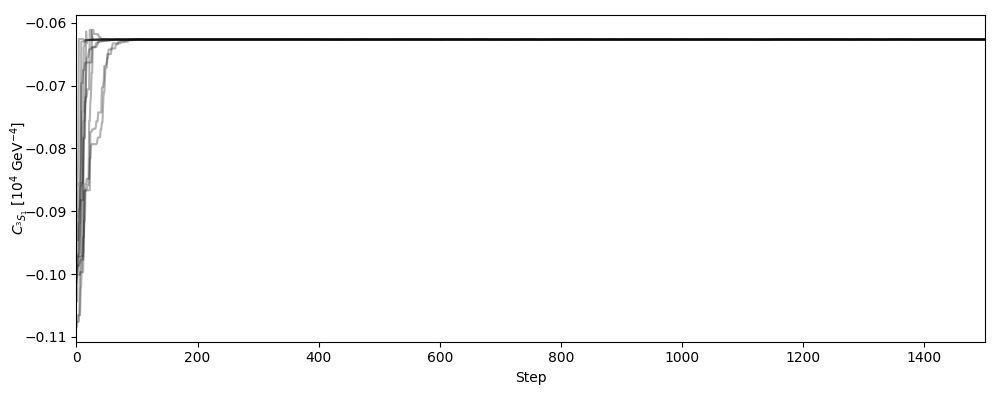

In [12]:
full_chain_LO_3S1 = sampler.get_chain()
np.save("full_chain_LO_3S1.npy", full_chain_LO_3S1)
labels = [r"$C_{^3S_1}$ [$10^4$ GeV$^{-4}$]"]

fig, axes = plt.subplots(ndim, figsize=(10, 4*len(labels)), sharex=True)
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(full_chain_LO_3S1[:, walker, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.set_xlim(0, len(full_chain_LO_3S1))
    ax.yaxis.set_label_coords(-0.05, 0.5)
axes[-1].set_xlabel("Step")
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
plt.show()

In [13]:
tau_LO_3S1 = sampler.get_autocorr_time() # FINORA È SEMBRATO ESSERE SOTTO AL 10, RIVERIFICARE CON PIÙ STEP
print(f"\nTempo di autocorrelazione per C_3S1 in caso LO: {tau_LO_3S1[0]:.1f} step")

discard_LO_3S1 = 5 * int(max(tau_LO_3S1))
print(f"\nConseguente numero di step di termalizzazione: {discard_LO_3S1} step")

thin_LO_3S1 = int(min(tau_LO_3S1))
print(f"\nConseguente numero di step per il thinning: {thin_LO_3S1} step")


Tempo di autocorrelazione per C_3S1 in caso LO: 19.0 step

Conseguente numero di step di termalizzazione: 90 step

Conseguente numero di step per il thinning: 18 step


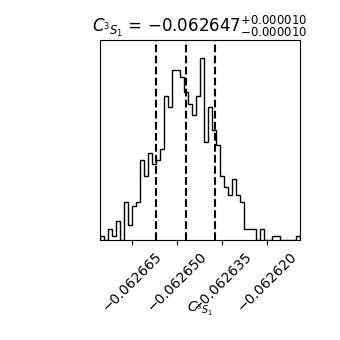

In [14]:
flat_samples_LO_3S1 = sampler.get_chain(discard=discard_LO_3S1, thin=thin_LO_3S1, flat=True)
labels = [r"$C_{^3S_1}$"]

figure = corner.corner(
    flat_samples_LO_3S1,
    labels=labels,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    title_fmt=".6f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=50,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

#

# Ordine NLO

Anche all'ordine NLO, noi continuiamo a considerare sempre e soli i due canali 1S0 e 3S1. Solo che stavolta, in ciascun canale, avremo più di un parametro solo. Concettualmente non cambia null'altro.

In [2]:
T_Lab = granada.Tlabs 

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

In [3]:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) 
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) 

## Canale 1S0:

In [4]:
def ln_prior_NLO_1S0(parameters):
    C_1S0, D_1S0 = parameters

    #if -5.0 < C_1S0 < 5.0 and -5.0 < D_1S0 < 5.0:
    #    return 0.0
    #return -np.inf 
    
    ln_P_C1S0 = -0.5 * ( np.log(2.0*np.pi * 2.25) + C_1S0**2 / 2.25 )
    ln_P_D1S0 = -0.5 * ( np.log(2.0*np.pi * 2.25) + D_1S0**2 / 2.25 )
    return ln_P_C1S0 + ln_P_D1S0

def ln_likelihood_NLO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0):
    NLO_lecs = {}
    NLO_lecs["C_1S0"] = parameters[0]
    NLO_lecs["D_1S0"] = parameters[1]

    # Parametri spenti:
    NLO_lecs["C_3S1"] = 0.0
    NLO_lecs["D_3S1"] = 0.0
    NLO_lecs["D_3S1-3D1"] = 0.0

    # Parametri non inferiti:
    NLO_lecs["D_1P1"] = 0.0
    NLO_lecs["D_3P0"] = 0.0
    NLO_lecs["D_3P1"] = 0.0
    NLO_lecs["D_3P2"] = 0.0

    nnstudio.lecs = NLO_lecs
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]
    ln_L_1S0 = -0.5 * np.sum( np.log(2.0*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    return ln_L_1S0

def ln_posterior_NLO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0):
    ln_pr = ln_prior_NLO_1S0(parameters)

    #if not np.isfinite(ln_pr):
    #    return -np.inf
    
    ln_post = ln_pr + ln_likelihood_NLO_1S0(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0)
    return ln_post

In [5]:
# Terza run: caso NLO, canale 1S0
ndim = 2
nwalkers = 10*ndim
nsteps = 2000

initial_guess = np.array([-0.15, +1.50])
initial_positions = initial_guess + 0.01 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            ln_posterior_NLO_1S0,
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error),
            pool=pool,
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(initial_positions, nsteps, progress=True)
    print("\nFinito! :)\n")

Eseguendo su 12 core...


100%|██████████| 2000/2000 [37:24<00:00,  1.12s/it]


Finito! :)



In [6]:
# Questo è un test suggerito da Opus per capire quale sia il problema di questa run.
# Concettualmente, il basin che cerchiamo è molto sottile, e proprio di fianco c'è una grossa regione con likelihood relativamente bassa.
# Questo vuol dire che se i walker non vengono inizializzati già molto vicini al risultato nominale, finiscono col perdersi!

#nn.V = chiral_potential.two_nucleon_potential("NLO", Lambda=500.0)
#Cs = np.linspace(-0.3, 0.0, 40)
#Ds = np.linspace(-3.0, 4.0, 40)
#L = np.zeros((len(Cs), len(Ds)))
#for a,C in enumerate(Cs):
#    for b,D in enumerate(Ds):
#        L[a,b] = ln_likelihood_NLO_1S0([C,D], nn, channel_1S0, shift_1S0, shift_1S0_error)
#plt.contourf(Ds, Cs, L, levels=50); plt.colorbar(); plt.xlabel("D_1S0"); plt.ylabel("C_1S0")

# È da considerare l'idea di mettere questo grafico in relazione come possibile spiegazione di walker che non convergono in questa run.
# Soprattutto se questa run sarà l'unica con walker che non convergono. Non ho ancora mai testato l'ultima run...

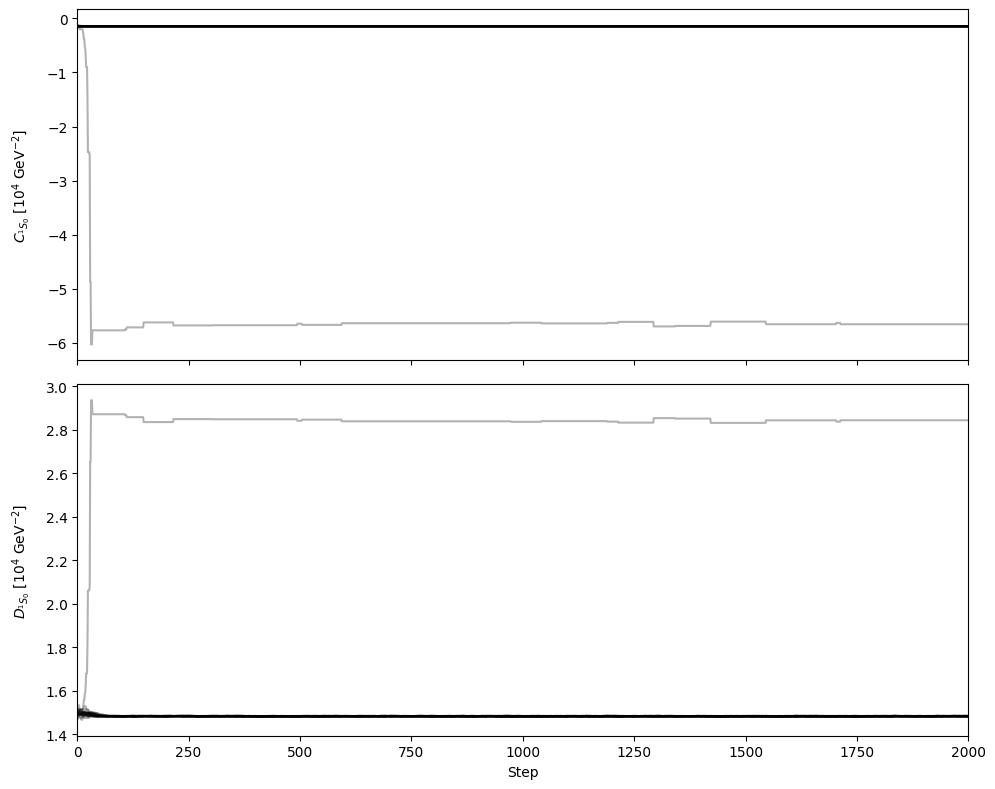

In [7]:
full_chain_NLO_1S0 = sampler.get_chain()
np.save("full_chain_NLO_1S0.npy", full_chain_NLO_1S0)
labels = [r"$C_{^1S_0}$ [$10^4$ GeV$^{-2}$]", r"$D_{^1S_0}$ [$10^4$ GeV$^{-2}$]"]

fig, axes = plt.subplots(ndim, figsize=(10, 4*len(labels)), sharex=True)
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(full_chain_NLO_1S0[:, walker, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.set_xlim(0, len(full_chain_NLO_1S0))
    ax.yaxis.set_label_coords(-0.05, 0.5)
axes[-1].set_xlabel("Step")
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
plt.show()

# Ci aspettiamo qualitativamente che finiamo con l'avere dei walker che fuggono via.
# A questo punto, dato che sappiamo qualitativamente la motivazione, lascerei così.

# Abbiamo già fatto il possibile con un prior non biasato che fosse centrato in zero e piuttosto stretto per naturalezza,
# e con un initial guess che fosse ispirato ai valori nominali. Lascerei i walker che fuggono a dimostrazione che questo specifico caso
# è numericamente poco stabile.

In [8]:
try:
    tau_NLO_1S0 = sampler.get_autocorr_time() # Tipicamente poco al di sotto di 25 => run ufficiale da 1500 step??
    print(f"\nTempo di autocorrelazione per C_1S0 in caso NLO: {tau_NLO_1S0[0]:.1f} step")
    print(f"Tempo di autocorrelazione per D_1S0 in caso NLO: {tau_NLO_1S0[1]:.1f} step")

    discard_NLO_1S0 = 5 * int(max(tau_NLO_1S0))
    print(f"\nConseguente numero di step di termalizzazione: {discard_NLO_1S0} step")

    thin_NLO_1S0 = int(min(tau_NLO_1S0))
    print(f"\nConseguente numero di step per il thinning: {thin_NLO_1S0} step")
except Exception as e:
    print(f"\nErrore nel calcolo del tempo di autocorrelazione: {e}")
    print("Probabilmente i walker non convergono, quindi non possiamo calcolare tau.")


Tempo di autocorrelazione per C_1S0 in caso NLO: 19.6 step
Tempo di autocorrelazione per D_1S0 in caso NLO: 38.4 step

Conseguente numero di step di termalizzazione: 190 step

Conseguente numero di step per il thinning: 19 step


In [9]:
# magheggio brutto e temporaneo (spero) per pulire la catena da walker che non convergono
#
#chain = sampler.get_chain(discard=burn_in, thin=thin, flat=False)
#
#best_fit = np.array([lec_values.nlo_lecs["C_1S0"], lec_values.nlo_lecs["D_1S0"]])
#
#clean_chain = []
#
#for walker in range(nwalkers):
#
#    single_walker_chain = chain[:, walker, :]
#
#    distance_from_best_fit = np.linalg.norm(single_walker_chain - best_fit)
#
#    if distance_from_best_fit < 1:
#        clean_chain.append(single_walker_chain)
#
#clean_chain = np.array(clean_chain)
#print(f"Number of walkers after cleaning: {len(clean_chain)}")
#print(clean_chain.shape)

In [10]:
#fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
#labels = ["C_1S0", "D_1S0"]
#
#for i in range(ndim):
#    ax = axes[i]
#    for walker in range(clean_chain.shape[0]):
#        ax.plot(clean_chain[walker, :, i], alpha=0.5)
#
#plt.show()

In [11]:
#flat_clean_chain = clean_chain.reshape(-1, ndim)
#
#corner.corner(flat_clean_chain, show_titles=True, title_fmt=".6f", truths=[lec_values.nlo_lecs["C_1S0"], lec_values.nlo_lecs["D_1S0"]])
#plt.suptitle("Corner plot dei campioni posteriors")
#plt.tight_layout()
#plt.show()

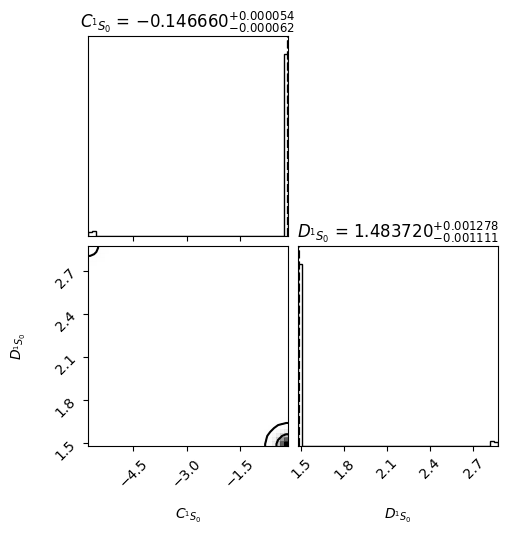

In [12]:
flat_samples_NLO_1S0 = sampler.get_chain(discard=40, thin=5, flat=True)
labels = [r"$C_{^1S_0}$", r"$D_{^1S_0}$"]

figure = corner.corner(
    flat_samples_NLO_1S0,
    labels=labels,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    title_fmt=".6f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=50,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

#

## Canale 3S1:

In [13]:
def ln_prior_NLO_3S1(parameters):
    C_3S1, D_3S1, D_mix = parameters
    ln_P_C3S1 = -0.5 * ( np.log(2.0*np.pi * 2.25) + C_3S1**2 / 2.25 )
    ln_P_D3S1 = -0.5 * ( np.log(2.0*np.pi * 2.25) + D_3S1**2 / 2.25 )
    ln_P_Dmix = -0.5 * ( np.log(2.0*np.pi * 2.25) + D_mix**2 / 2.25 )
    return ln_P_C3S1 + ln_P_D3S1 + ln_P_Dmix

def ln_likelihood_NLO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    NLO_lecs = {}
    NLO_lecs["C_3S1"] = parameters[0]
    NLO_lecs["D_3S1"] = parameters[1]
    NLO_lecs["D_3S1-3D1"] = parameters[2]
    
    NLO_lecs["C_1S0"] = 0.0
    NLO_lecs["D_1S0"] = 0.0
    
    NLO_lecs["D_1P1"] = 0.0
    NLO_lecs["D_3P0"] = 0.0
    NLO_lecs["D_3P1"] = 0.0
    NLO_lecs["D_3P2"] = 0.0
    
    nnstudio.lecs = NLO_lecs
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:, 0]
    teo_3D1 = nnstudio.phase_shifts[0][:, 1]
    teo_mix = nnstudio.phase_shifts[0][:, 2]
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    ln_L_3D1 = -0.5 * np.sum( np.log(2*np.pi * err_3D1**2) + ((exp_3D1-teo_3D1) / err_3D1)**2 )
    ln_L_mix = -0.5 * np.sum( np.log(2*np.pi * err_mix**2) + ((exp_mix-teo_mix) / err_mix)**2 )

    # Calcolo dell'energia:
    _, mu = nnstudio.lab2rel(0, 0)
    N = 2 * nnstudio.Np
    H = np.zeros((N, N))
    T = np.zeros((N, N))
    ww = np.hstack((nnstudio.wmesh, nnstudio.wmesh))
    pp = np.hstack((nnstudio.pmesh, nnstudio.pmesh))
    V = nnstudio.setup_Vmtx(chn_3S1[0])[0]
    for i, p_bra in enumerate(pp):
        for j, p_ket in enumerate(pp):
            if i == j:
                T[i, j] = p_bra**2 / (2 * mu)
            V[i, j] = V[i, j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
    H = T + V
    eigvals, eigvecs = linalg.eigh(H)
    srt = np.argsort(eigvals)
    E_teo = eigvals[srt[0]]
    E_obs = -2.224
    E_err = -E_obs * 0.05
    ln_L_E = -0.5 * ( np.log(2.0*np.pi * E_err**2) + ((E_obs - E_teo) / E_err)**2 )

    # Calcolo del quadrupolo:
    phi_gs = eigvecs[:, srt[0]]
    psi_gs = phi_gs / (pp * np.sqrt(ww))
    u = psi_gs[:nnstudio.Np]
    w = psi_gs[nnstudio.Np:]
    if u[np.argmax(np.abs(u))] < 0:
        u *= -1
        w *= -1
    idx = np.argsort(nnstudio.pmesh)
    p = nnstudio.pmesh[idx]
    spline_u = CubicSpline(p, u[idx])
    spline_w = CubicSpline(p, w[idx])
    du = spline_u(p, 1)
    dw = spline_w(p, 1)
    u = u[idx]
    w = w[idx]
    wmesh = nnstudio.wmesh[idx]
    SD_term = (-np.sqrt(8)/20) * (p**2 * dw * du + 3 * p * w * du)
    DD_term = (-1/20) * (p**2 * dw**2 + 6 * w**2)
    Q_teo = np.sum(wmesh * (SD_term + DD_term))
    Q_teo *= hbarc**2
    if Q_teo < 0:
        Q_teo *= -1
    Q_obs = 0.286
    Q_err = Q_obs * 0.05
    ln_L_Q = -0.5 * ( np.log(2.0*np.pi * Q_err**2) + ((Q_obs - Q_teo) / Q_err)**2 )
    
    return ln_L_3S1 + ln_L_3D1 + ln_L_mix + ln_L_E #+ ln_L_Q

def ln_posterior_NLO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    ln_pr = ln_prior_NLO_3S1(parameters)
    ln_post = ln_pr + ln_likelihood_NLO_3S1(parameters, nnstudio, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix)
    return ln_post

In [14]:
# Quarta run: caso NLO, canale 3S1
ndim = 3
nwalkers = 10*ndim # Questa run è impostata per essere preliminare. Vediamo quant'è tipicamente l'autocorrelazione prima!
nsteps = 3000

initial_guess = np.array([-0.15, -1.00, +0.15])
initial_positions = initial_guess + 0.01 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            ln_posterior_NLO_3S1,
            args=(nn, channel_3S1, shift_3S1, shift_3S1_error, shift_3D1, shift_3D1_error, shift_mix, shift_mix_error),
            pool=pool,
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(initial_positions, nsteps, progress=True)
    print("\nFinito! :)\n")

Eseguendo su 12 core...


100%|██████████| 3000/3000 [16:36:03<00:00, 19.92s/it]  


Finito! :)



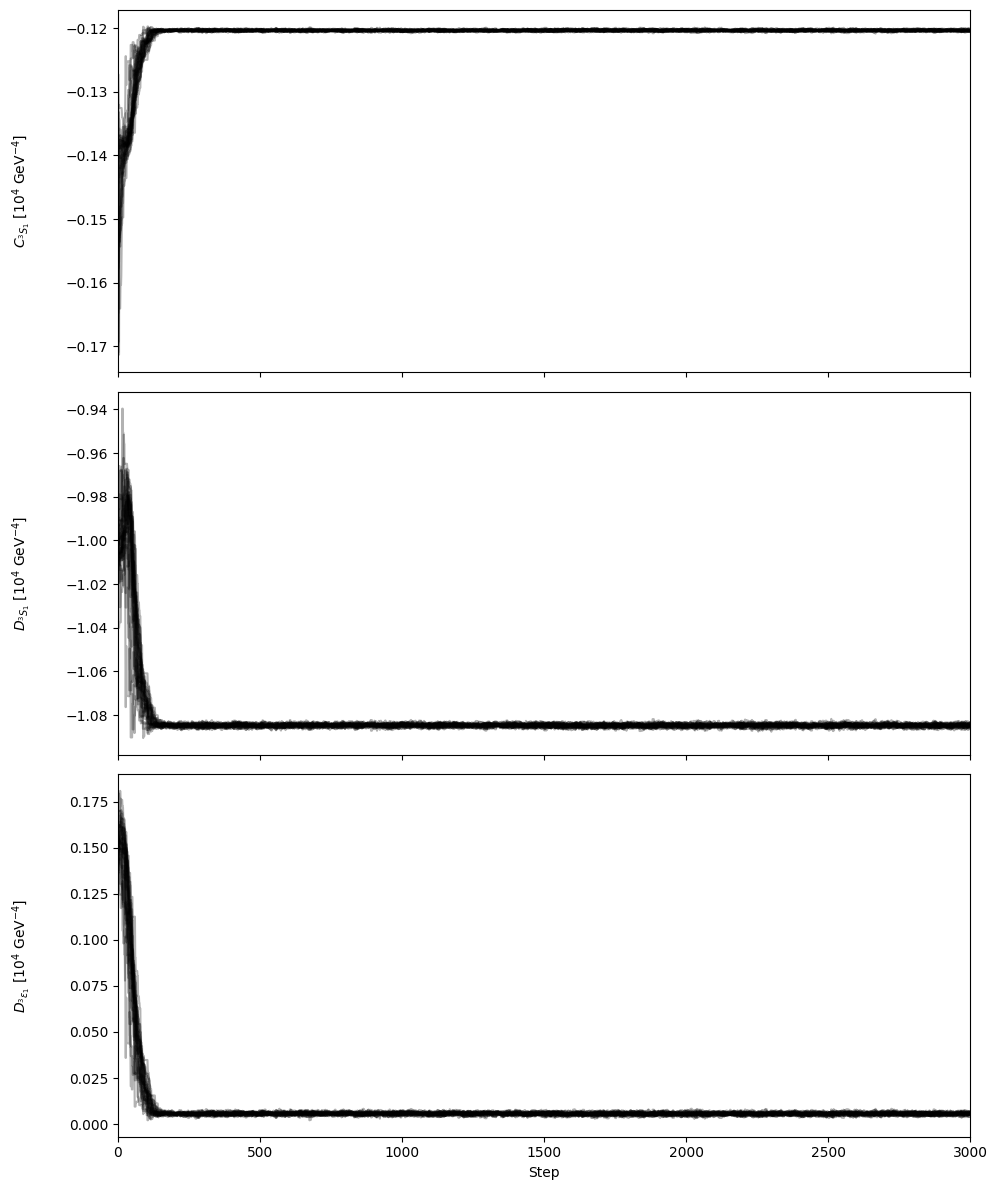

In [15]:
full_chain_NLO_3S1 = sampler.get_chain()
np.save("full_chain_NLO_3S1.npy", full_chain_NLO_3S1)
labels = [r"$C_{^3S_1}$ [$10^4$ GeV$^{-4}$]", r"$D_{^3S_1}$ [$10^4$ GeV$^{-4}$]", r"$D_{^3\varepsilon_1}$ [$10^4$ GeV$^{-4}$]"]

fig, axes = plt.subplots(ndim, figsize=(10, 4*len(labels)), sharex=True)
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(full_chain_NLO_3S1[:, walker, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.set_xlim(0, len(full_chain_NLO_3S1))
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step")
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
plt.show()

In [16]:
try:
    tau_NLO_3S1 = sampler.get_autocorr_time() # Tipicamente ???????? ################################################
    print(f"\nTempo di autocorrelazione per C_3S1 in caso NLO: {tau_NLO_3S1[0]:.1f} step")
    print(f"Tempo di autocorrelazione per D_3S1 in caso NLO: {tau_NLO_3S1[1]:.1f} step")
    print(f"Tempo di autocorrelazione per D_mix in caso NLO: {tau_NLO_3S1[2]:.1f} step")

    discard_NLO_3S1 = 5 * int(max(tau_NLO_3S1))
    print(f"\nConseguente numero di step di termalizzazione: {discard_NLO_3S1} step")

    thin_NLO_3S1 = int(min(tau_NLO_3S1))
    print(f"\nConseguente numero di step per il thinning: {thin_NLO_3S1} step")
except Exception as e:
    print(f"\nErrore nel calcolo del tempo di autocorrelazione: {e}")
    print("Probabilmente i walker non convergono, quindi non possiamo calcolare tau.")


Errore nel calcolo del tempo di autocorrelazione: The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [73.34879144 77.69105728 73.2782367 ]
Probabilmente i walker non convergono, quindi non possiamo calcolare tau.


In [17]:
flat_samples_NLO_3S1 = sampler.get_chain(discard=discard_NLO_3S1, thin=thin_NLO_3S1, flat=True)
labels = [r"$C_{^3S_1}$", r"$D_{^3S_1}$", r"$D_{^3\varepsilon_1}$"]

figure = corner.corner(
    flat_samples_NLO_3S1,
    labels=labels,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    title_fmt=".6f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=50,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

NameError: name 'discard_NLO_3S1' is not defined